<a href="https://colab.research.google.com/github/eljaysmithdata/Data-Science-Bootcamp-2026/blob/main/Project-6/Project_6_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6: Deep Learning



## Problem Statement

The goal of this project is to build a deep learning model that can classify images as either **cats** or **dogs**.

This is a **binary image classification problem** because the model is choosing between two possible classes:

- Cat
- Dog

The model will learn visual patterns from labeled images, such as edges, textures, shapes, ears, faces, and fur patterns. After training, the model will be evaluated using test accuracy, loss curves, prediction probabilities, and example predictions on new images.

The target variable is the image label, which tells the model whether each image belongs to the cat class or the dog class.

## Sound Engineering Analogy

For this project, the neural network is like a sound engineer learning to recognize two different instruments by listening to many examples.

At first, the model only hears raw visual “noise.” Through training, it learns which visual frequencies matter: edges, shapes, textures, and patterns. By the end, the model should be able to hear the difference between the “cat track” and the “dog track.”

## Imports

In this section, I import the Python libraries needed for the project.

These libraries help with:

- loading and organizing data
- working with image arrays
- building a convolutional neural network
- splitting the data into training and testing sets
- evaluating model performance
- creating visualizations
- preparing outside images for prediction

Data science thought process: before building the model, I need to load the tools that will help me prepare the data, train the neural network, and evaluate whether the model is actually learning.

In [ ]:
# ============================
# Imports
# ============================

# Basic data and math tools
import pandas as pd
import numpy as np

# Visualization tools
import matplotlib.pyplot as plt

# Tools for working with URLs and temporary image files
import requests
import tempfile

# Train/test split
from sklearn.model_selection import train_test_split

# Model evaluation tools
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# TensorFlow / Keras tools for deep learning
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Image loading tools for outside image predictions
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array

## Reproducibility

Before modeling, I set random seeds so the notebook results are more consistent when the code is rerun.

Data science thought process: some parts of machine learning involve randomness, such as splitting the data and initializing model weights. Setting seeds helps make the workflow easier to reproduce.

In [ ]:
# ============================
# Set Random Seeds
# ============================

# Set NumPy random seed
np.random.seed(42)

# Set TensorFlow random seed
tf.random.set_seed(42)

## GPU Check

Deep learning can involve a lot of calculations. A GPU can help speed up training because it is designed to process many calculations at the same time.

Data science thought process: before training the neural network, I want to check whether the notebook has access to GPU acceleration.

In [ ]:
# ============================
# Check for GPU
# ============================

# Check whether TensorFlow can find a GPU
gpu_devices = tf.config.list_physical_devices("GPU")

# Print whether a GPU is available
print("GPU available:", len(gpu_devices) > 0)

# Print the GPU device if one is found
if len(gpu_devices) > 0:
    print("GPU device:", gpu_devices[0])
else:
    print("No GPU detected. The model can still run, but training may be slower.")

GPU available: False
No GPU detected. The model can still run, but training may be slower.


** A GPU is helpful, but it is not required for this project. Since no GPU was detected, the notebook can still run, but model training may take longer.

## Data Collection

The image data for this project is provided in two pickle files:

- `X.pickle` contains the image data
- `y.pickle` contains the labels

Each image is represented as a numerical array. The labels tell the model whether each image is a cat or a dog.

Data science thought process: before cleaning or modeling the data, I need to load the raw image arrays and labels, then check their shapes to make sure they match.

Sound engineering analogy: this is like importing the raw audio tracks into the studio before mixing. I am not changing the signal yet — I am just bringing the tracks into the session and checking what I have.
Cell 7 — Code

In [ ]:
# ============================
# Load Data
# ============================

# URLs for the pickle files
X_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
y_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"

# Load the pickle files
X_raw = pd.read_pickle(X_url)
y_raw = pd.read_pickle(y_url)

# Convert the data into NumPy arrays
X_raw = np.array(X_raw)
y_raw = np.array(y_raw)

# Check that the data loaded correctly
print("Raw image data shape:", X_raw.shape)
print("Raw label data shape:", y_raw.shape)

Raw image data shape: (24946, 100, 100, 1)
Raw label data shape: (24946,)


## Initial Data Check

Before cleaning the data, I need to inspect the structure of the image arrays and labels.

For image classification, the model usually expects the image data to be 4-dimensional:

`number of images, image height, image width, color channels`

The labels should match the number of images. Each image needs one correct label so the model can learn the relationship between the visual patterns and the answer.

Data science thought process: checking the shape of the data early helps prevent errors later. If the image data is not in the right format, the neural network will not know how to read the images.

In [ ]:
# ============================
# Initial Data Check
# ============================

# Check the shape of the image data and label data
print("X_raw shape:", X_raw.shape)
print("y_raw shape:", y_raw.shape)

# Check the number of dimensions
# Data science thought process:
# CNN image data should be 4-dimensional:
# number of images, image height, image width, color channels.
print("X_raw dimensions:", X_raw.ndim)
print("y_raw dimensions:", y_raw.ndim)

# Confirm whether the raw image data is 4-dimensional
if X_raw.ndim == 4:
    print("Confirmed: X_raw is 4-dimensional.")
    print("Image shape:", X_raw.shape[1:])
else:
    print("Warning: X_raw is not 4-dimensional.")
    print("Current shape:", X_raw.shape)

# Check the shape of one image
print("Shape of one image:", X_raw[0].shape)

# Check the first 10 labels
print("First 10 labels:", y_raw[:10])

# Confirm that the number of images matches the number of labels
if X_raw.shape[0] == y_raw.shape[0]:
    print("Confirmed: The number of images matches the number of labels.")
else:
    print("Warning: The number of images does not match the number of labels.")
    print("Number of images:", X_raw.shape[0])
    print("Number of labels:", y_raw.shape[0])

X_raw shape: (24946, 100, 100, 1)
y_raw shape: (24946,)
X_raw dimensions: 4
y_raw dimensions: 1
Confirmed: X_raw is 4-dimensional.
Image shape: (100, 100, 1)
Shape of one image: (100, 100, 1)
First 10 labels: [0 1 1 0 0 0 0 0 0 0]
Confirmed: The number of images matches the number of labels.


The image dataset is 4-dimensional, which is the expected structure for CNN image modeling.

The shape shows the number of images, image height, image width, and color channels. The label array contains one label for each image.

## First Look at One Image

Before cleaning or modeling, I will display one image to make sure the data loaded correctly.

Data science thought process: visual inspection is important with image data. Even if the shape looks correct, I still want to confirm that the images are readable.

Sound engineering analogy: this is like soloing one track in the mix. Before adjusting anything, I need to hear what one raw track sounds like.

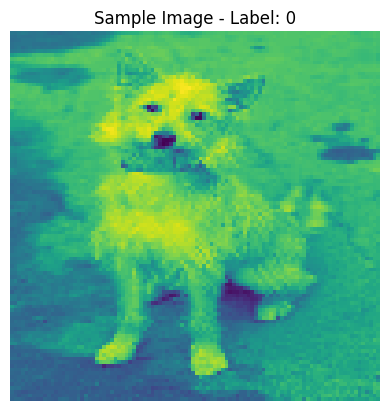

In [ ]:
# ============================
# Display One Image
# ============================

# Select the first image
sample_image = X_raw[0]
sample_label = y_raw[0]

# Display the image
plt.imshow(sample_image)
plt.title(f"Sample Image - Label: {sample_label}")
plt.axis("off")
plt.show()

At this stage, the labels are still numeric. Later in the project, I will interpret what each label means and use those labels to evaluate the model.

## Data Cleaning

The next step is to clean the image data by scaling the pixel values.

Image pixel values usually range from 0 to 255:

- 0 means very dark
- 255 means very bright

Neural networks usually train better when the input values are smaller and more consistent. To do this, I will divide the image data by 255 so the values fall between 0 and 1.

Data science thought process: scaling the data helps the model learn more smoothly. The model is still seeing the same images, but the numbers are easier for the neural network to process.

Sound engineering analogy: this is like normalizing the volume before mixing. I am not changing the song — I am adjusting the signal so the model can hear it more clearly.

In [ ]:
# ============================
# Data Cleaning: Scale Images
# ============================

# Check pixel value range before scaling
print("Before scaling:")
print("Minimum pixel value:", X_raw.min())
print("Maximum pixel value:", X_raw.max())

# Scale image values from 0-255 to 0-1
X = X_raw.astype("float32") / 255.0

# Keep labels in a clean variable
y = y_raw

# Check pixel value range after scaling
print("\nAfter scaling:")
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

# Check cleaned data shapes
print("\nCleaned data shapes:")
print("X shape:", X.shape)
print("y shape:", y.shape)

Before scaling:
Minimum pixel value: 0
Maximum pixel value: 255

After scaling:
Minimum pixel value: 0.0
Maximum pixel value: 1.0

Cleaned data shapes:
X shape: (24946, 100, 100, 1)
y shape: (24946,)


In [ ]:
# ============================
# Confirm Cleaned Image Dimensions
# ============================

# Confirm that the cleaned image data is still 4-dimensional
print("X dimensions:", X.ndim)
print("X shape:", X.shape)

# Confirm whether the image data is ready for CNN modeling
if X.ndim == 4:
    print("Confirmed: X is 4-dimensional and ready for CNN modeling.")
else:
    print("Warning: X is not 4-dimensional. Check the image data shape before modeling.")

X dimensions: 4
X shape: (24946, 100, 100, 1)
Confirmed: X is 4-dimensional and ready for CNN modeling.


The pixel values are now scaled from 0 to 1. This helps the neural network train more efficiently because the input values are smaller and more consistent.

The cleaned image data is still 4-dimensional, which means it is still in the correct format for a CNN.

## Label Check and Class Balance

Since this is a binary classification problem, I expect the target labels to contain two classes: dogs and cats.

In this section, I will check:

- how many images belong to each class
- whether the classes are balanced
- whether the dataset has enough examples of both dogs and cats for the model to learn

Data science thought process: if one class has many more images than the other, the model may become biased toward the larger class. A balanced dataset gives the model a fairer chance to learn both categories.

Sound engineering analogy: this is like checking whether both tracks are present at similar volume before mixing. If the dog track is loud and the cat track is barely audible, the model may learn to mostly hear dogs.

In [ ]:
# ============================
# Label Check and Class Balance
# ============================

# Create readable names for the labels
# Based on visual inspection:
# Label 0 = Dog
# Label 1 = Cat
class_names = {
    0: "Dog",
    1: "Cat",
}

# Count the number of images in each class
unique_labels, label_counts = np.unique(
    y,
    return_counts=True,
)

# Create a small summary table
label_summary = pd.DataFrame(
    {
        "Label": unique_labels,
        "Class": [class_names[label] for label in unique_labels],
        "Number of Images": label_counts,
    }
)

# Display the summary table
print(label_summary.to_string(index=False))

 Label Class  Number of Images
     0   Dog             12470
     1   Cat             12476


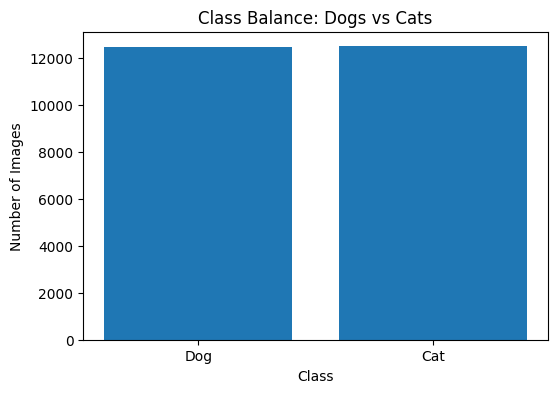

In [ ]:
# ============================
# Plot Class Balance
# ============================

# Plot the number of dog and cat images
plt.figure(figsize=(6, 4))

plt.bar(
    label_summary["Class"],
    label_summary["Number of Images"],
)

plt.title("Class Balance: Dogs vs Cats")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

The target variable contains two classes: dog images and cat images.

The class counts are very similar, which means the dataset is balanced. This is helpful because the model will have about the same number of dog and cat examples to learn from.

This gives me more confidence that accuracy will be a meaningful evaluation metric for this project.

## Exploratory Data Analysis

In this section, I will explore the image data by displaying multiple images and their labels.

The instructor specifically asked us to plot more than 5 images and look at the response values for those images. I will display 9 sample images so I can visually check whether the image data and labels appear to match.

Data science thought process: before training a model, I need to understand what the model will be learning from. With image data, visual inspection is especially important because shape checks only tell me the structure of the data — they do not show whether the images themselves make sense.

Sound engineering analogy: this is like listening to several raw tracks before mixing. I am checking the signal before asking the model to learn from it.

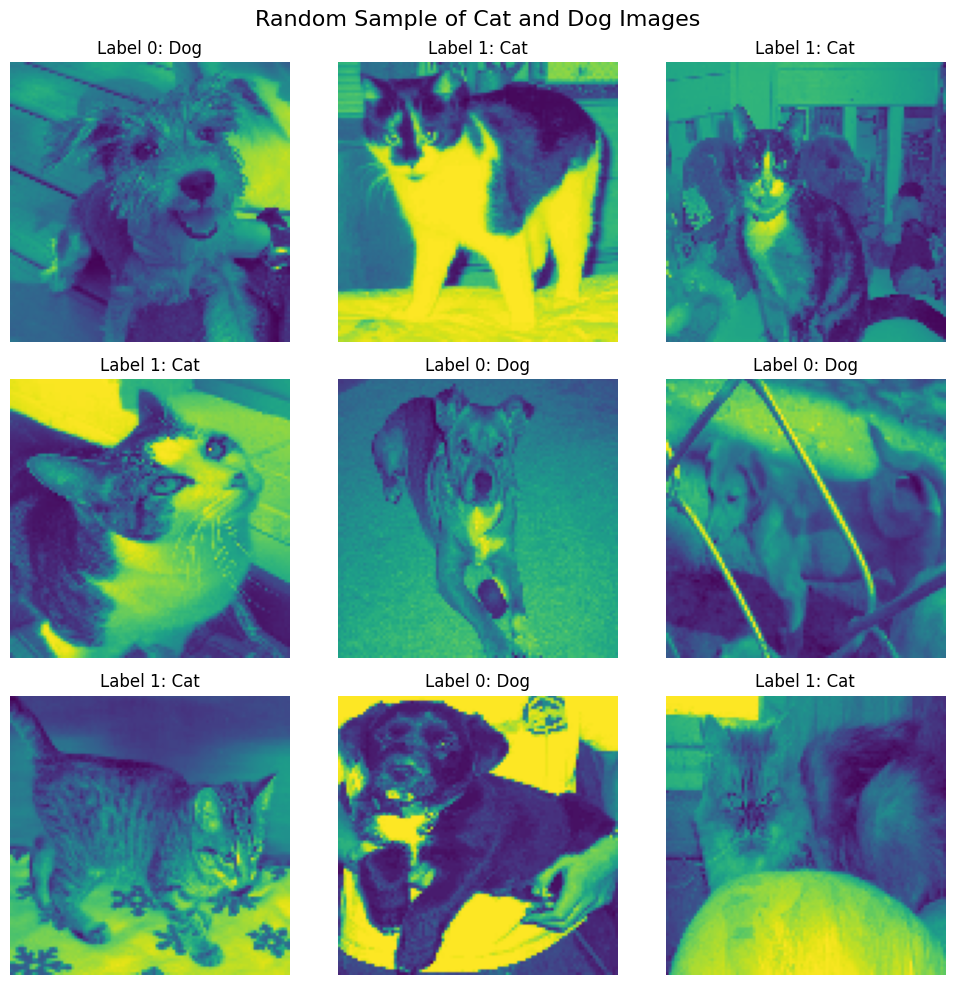

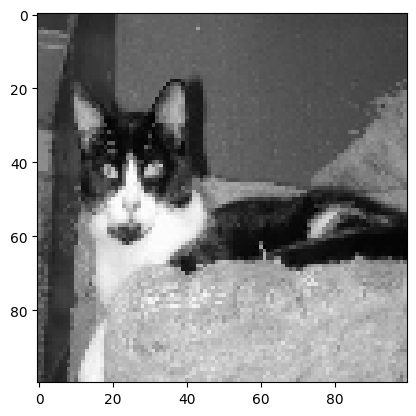

In [ ]:
# ============================
# Exploratory Data Analysis: Display Random Sample Images
# ============================

# Create readable names for the labels
class_names = {
    0: "Dog",
    1: "Cat",
}

# Choose 9 random images from the dataset
random_indexes = np.random.choice(
    len(X),
    size=9,
    replace=False,
)

# Set up the figure
plt.figure(figsize=(10, 10))

# Display the random images
for i, index in enumerate(random_indexes):
    plt.subplot(3, 3, i + 1)

    # Get image and label
    image = X[index]
    label_number = y[index]
    label_name = class_names[label_number]

    # Display image
    plt.imshow(image)

    # Add title with both numeric label and class name
    plt.title(f"Label {label_number}: {label_name}")
    plt.axis("off")

plt.suptitle("Random Sample of Cat and Dog Images", fontsize=16)
plt.tight_layout()
plt.show()

plt.imshow(X[95],cmap="gray")

The sample images show that the dataset contains small color images of cats and dogs. The labels appear to match the images, and the classes are balanced.

This confirms that the image data and target labels are usable for binary classification.

Data science thought process: visual inspection helps confirm that the data makes sense before modeling. The model will learn from these image patterns, so I want to make sure the images and labels are lined up correctly.

Sound engineering analogy: this is like listening to a few raw tracks before mixing. Before training the model, I am checking that the signal is clear enough to work with.

## Data Processing

Before building the neural network, I need to split the data into training and testing sets.

The training set is used to teach the model. The testing set is held back so I can evaluate how well the model performs on images it has not seen before.

Data science thought process: this helps me check whether the model is actually learning general patterns, instead of just memorizing the training images.

Sound engineering analogy: the training set is like practicing with the studio recording. The test set is like hearing the song performed live. If the model only memorized the studio version, it may fail when it hears something new.

In [ ]:
# ============================
# Data Processing: Train/Test Split
# ============================

# Split the cleaned image data and labels into training and testing sets
# Data science thought process:
# The model learns from the training data and is evaluated on unseen test data.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Check the shape of each split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (19956, 100, 100, 1)
X_test shape: (4990, 100, 100, 1)
y_train shape: (19956,)
y_test shape: (4990,)


The data has now been split into training and testing sets.

I used `stratify=y` so the dog and cat classes stay balanced in both the training set and the testing set. This helps create a fairer evaluation because the model will be tested on a similar class balance to the original dataset.

### Deep Learning Model

For this project, I will build a convolutional neural network, also called a CNN.

A CNN is a good fit for image classification because it can learn visual patterns from image data. The convolutional layers look for small patterns like edges, textures, curves, and shapes. The pooling layers reduce the size of the image information while keeping the strongest signals.

I am building the model step by step in separate cells so that if something breaks, it is easier to identify which layer caused the issue.

Data science thought process: building the model in small steps makes the workflow easier to debug and understand.

Sound engineering analogy: this is like building a mix one track at a time. Instead of turning every knob at once, I add one layer, check the signal, then move to the next layer.

#### Build Model

The model will be built using Keras `Sequential`, which means the layers are stacked one after another.

In [ ]:
# ============================
# Start Sequential Model
# ============================

# Start with an empty Sequential model
model = Sequential()

##### Input Layer

The input layer tells the model what shape of image data to expect.

Instead of hard-coding `(100, 100, 3)`, I use `X_train.shape[1:]`. This pulls the image shape directly from the training data.

Data science thought process: using the training data shape helps prevent mistakes if the image size changes later. The model should match the actual structure of the data.

Sound engineering analogy: this is like checking the format of the track before mixing. Before the model can listen, it needs to know what kind of signal is coming in.

In [ ]:
# ============================
# Add Input Layer
# ============================

# Define input layer
# Data science thought process:
# X_train.shape[1:] gives the shape of one image without the number of images.
# For this project, that shape is: height, width, color channels.
model.add(
    Input(
        shape=X_train.shape[1:],
        name="model_input",
    ),
)

##### First Hidden Layer

The first hidden layer uses a convolutional layer to start learning visual patterns from the images, such as edges, corners, textures, and simple shapes.

This layer also includes max pooling, which reduces the size of the image information while keeping the strongest features.

Data science thought process: the first hidden layer helps the model begin detecting basic image features that may help separate dogs from cats.

Sound engineering analogy: this layer is like the first EQ pass in a mix. It starts listening for the strongest visual frequencies in the image signal.

In [ ]:
# ============================
# First Hidden Layer
# ============================

# Add first convolutional layer
# Data science thought process:
# This layer begins learning simple visual features from the image data.
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        name="conv_1",
    ),
)

# Add first max pooling layer
# Data science thought process:
# Pooling reduces the image size while keeping the strongest learned features.
model.add(
    MaxPooling2D(
        pool_size=(2, 2),
        name="max_pooling_1",
    ),
)

##### Second Hidden Layer

The second hidden layer gives the model another opportunity to learn visual patterns from the image data.

The first hidden layer may detect simpler features, such as edges, corners, and textures. The second hidden layer can build on those earlier patterns and begin learning more complex image features.

This layer also includes max pooling, which reduces the size of the feature maps while keeping the strongest signals.

Data science thought process: adding a second hidden layer gives the CNN more capacity to learn useful patterns for separating dogs from cats.

Sound engineering analogy: this is like a second EQ pass. After the first layer picks up the basic frequencies, this layer listens for more developed patterns in the mix.
Code Cell

In [ ]:
# ============================
# Second Hidden Layer
# ============================

# Add second convolutional layer
# Data science thought process:
# This layer builds on the first hidden layer by learning more complex image features.
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        name="conv_2",
    ),
)

# Add second max pooling layer
# Data science thought process:
# Pooling reduces the feature map size while keeping the strongest learned patterns.
model.add(
    MaxPooling2D(
        pool_size=(2, 2),
        name="max_pooling_2",
    ),
)

##### Flatten Layer

The convolutional and pooling layers produce image feature maps. Before sending those features into the dense layers, I need to flatten those feature maps into a one-dimensional vector.

Data science thought process: the convolutional layers learned visual features from the images. The flatten layer converts those learned features into a format the final classification layers can use.

Sound engineering analogy: this is like taking the layered visual signal and routing it into one clear channel before the final mix decision.

In [ ]:
# ============================
# Flatten Layer
# ============================

# Flatten the image features into a 1D vector
# Data science thought process:
# Dense layers need a flat input, so this step converts feature maps
# into a format the classification layers can use.
model.add(
    Flatten(
        name="flatten",
    ),
)

##### Dense and Dropout Layers

The dense layer combines the learned image features and looks for patterns that separate dogs from cats.

The dropout layer randomly turns off some neurons during training. This helps reduce overfitting by making the model less dependent on memorizing exact training images.

Data science thought process: the dense layer helps make the final classification decision, while dropout helps the model generalize better to new images.

Sound engineering analogy: dropout is like forcing the model to recognize the song even when part of the track drops out. If it really understands the pattern, it should still recognize the signal.

In [ ]:
# ============================
# Dense and Dropout Layers
# ============================

# Add dense hidden layer
# Data science thought process:
# This layer combines the learned image features to help classify dogs vs cats.
model.add(
    Dense(
        units=128,
        activation="relu",
        name="dense_1",
    ),
)

# Add dropout layer to reduce overfitting
# Data science thought process:
# Dropout helps prevent the model from memorizing the training images too closely.
model.add(
    Dropout(
        rate=0.5,
        name="dropout",
    ),
)

##### Output Layer

The output layer makes the final prediction.

Because this is a binary classification problem, the model only needs one output neuron. The sigmoid activation function gives a probability between 0 and 1.

A value closer to 0 means the model is leaning toward dog. A value closer to 1 means the model is leaning toward cat.

Data science thought process: sigmoid is appropriate here because the model is predicting between two possible classes.
A value closer to 0 means the model is leaning toward dog. A value closer to 1 means the model is leaning toward cat.

In [ ]:
# ============================
# Output Layer
# ============================

# Add final output layer for binary classification
# Data science thought process:
# One output neuron with sigmoid gives a probability for the positive class.
model.add(
    Dense(
        units=1,
        activation="sigmoid",
        name="output",
    ),
)

#### Review Model Structure

The model summary shows each layer, the output shape, and the number of trainable parameters.

This helps confirm that the model was built correctly before compiling and training.

Data science thought process: reviewing the model structure helps catch layer-shape problems before training begins.

In [ ]:
# ============================
# Review Model Structure
# ============================

# Display the model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_1 (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_2 (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     4,333,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,352,641 (16.60 MB)

 Trainable params: 4,352,641 (16.60 MB)

 Non-trainable params: 0 (0.00 B)

The model summary confirms that the CNN has been built layer by layer.

This model includes an input layer, two hidden layers with convolution and pooling, a flatten layer, a dense layer, dropout, and a final sigmoid output layer for binary classification.

Important note: if I rerun the model-building section, I should start again from the `model = Sequential()` cell. Otherwise, layers may accidentally be added more than once.

#### Compile Model

Before training the model, I need to compile it.

Compiling tells the model:

- how to measure error
- how to improve during training
- what performance metric to track

Because this is a binary classification problem, I will use `binary_crossentropy` as the loss function. I will use `accuracy` as the main performance metric.

Data science thought process: compiling sets the rules for how the model learns from mistakes.

Sound engineering analogy: this is like setting the mixing board before recording. The model needs to know what counts as distortion, how to adjust itself, and what signal quality to track.

In [ ]:
# ============================
# Compile Model
# ============================

# Compile the model for binary classification
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

The model is now compiled and ready to train.

`binary_crossentropy` is appropriate because there are two possible classes: dog or cat. Accuracy will track the percentage of correct predictions.

#### Fit / Train Model

Now I will train the CNN using the training data.

During training, the model looks at many examples of cats and dogs. Each full pass through the training data is called an epoch.

I am using validation data during training so I can compare how the model performs on data it is learning from versus data it has not directly trained on. This helps me watch for overfitting.

Sound engineering analogy: training is repeated listening. The model hears the track multiple times, adjusts its filters, and slowly learns which visual patterns matter.

In [ ]:
# ============================
# Define Early Stopping
# ============================

# Early stopping can stop training if validation loss stops improving
# Data science thought process:
# This helps prevent the model from overtraining on the training data.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

In [ ]:
# ============================
# Fit Model
# ============================

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=4,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
)
# print("Model training is complete.")

Epoch 1/4
499/499 ━━━━━━━━━━━━━━━━━━━━ 266s 529ms/step - accuracy: 0.6240 - loss: 0.6481 - val_accuracy: 0.7114 - val_loss: 0.5753
Epoch 2/4
499/499 ━━━━━━━━━━━━━━━━━━━━ 324s 534ms/step - accuracy: 0.7259 - loss: 0.5467 - val_accuracy: 0.7472 - val_loss: 0.5097
Epoch 3/4
499/499 ━━━━━━━━━━━━━━━━━━━━ 291s 472ms/step - accuracy: 0.7748 - loss: 0.4729 - val_accuracy: 0.7603 - val_loss: 0.4994
Epoch 4/4
499/499 ━━━━━━━━━━━━━━━━━━━━ 275s 499ms/step - accuracy: 0.8112 - loss: 0.4149 - val_accuracy: 0.7668 - val_loss: 0.5056


After training, I will visualize the model's training and validation accuracy.

This plot helps answer: did the model improve as it trained?

If training accuracy and validation accuracy both improve, the model is learning useful patterns. If training accuracy rises much higher than validation accuracy, the model may be memorizing the training data instead of generalizing.

#### Plot Training History

After training, I will visualize the model's accuracy and loss over time.

These plots help show whether the model improved during training and whether the training and validation results stayed close together.

Data science thought process: learning curves help diagnose overfitting, underfitting, or healthy model learning.

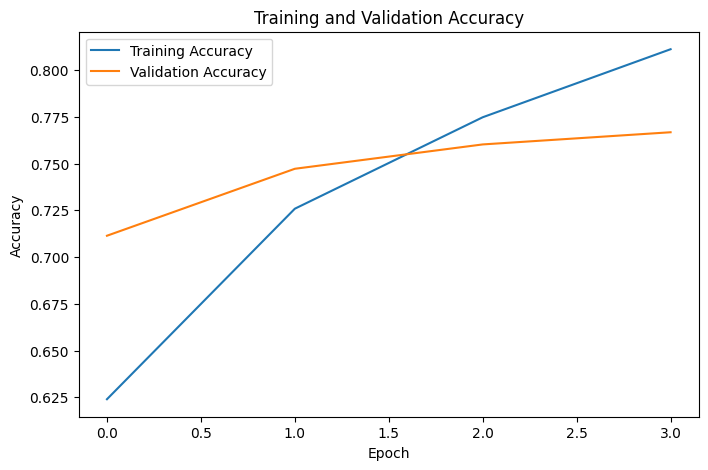

In [ ]:
# ============================
# Plot Training Accuracy
# ============================

# Plot training and validation accuracy over each epoch
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### Plot Training Loss

Next, I will visualize the model's training and validation loss.

Loss measures how wrong the model is. Lower loss is better.

If both training loss and validation loss decrease, the model is learning. If validation loss starts increasing while training loss keeps decreasing, that can be a warning sign of overfitting.

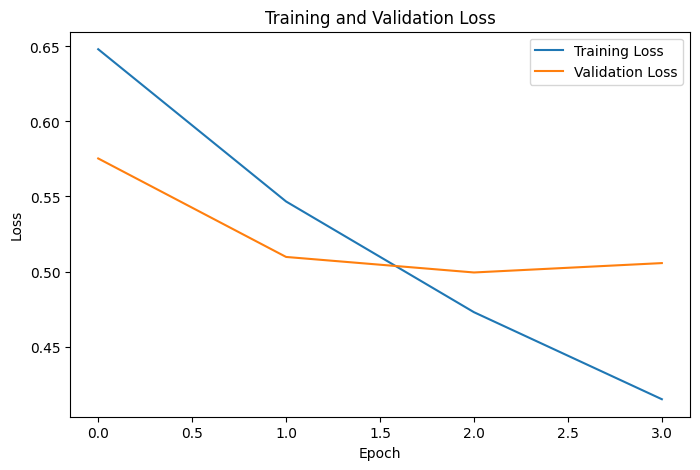

In [ ]:
# ============================
# Plot Training Loss
# ============================

# Plot training and validation loss over each epoch
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

The training history plots show how the model learned over time.

If validation accuracy improves along with training accuracy, that suggests the model is learning useful patterns. If training accuracy improves while validation accuracy gets worse, that may suggest overfitting.

#### Evaluate Model

After training, I will evaluate the model on the test set.

The test set was not used during training, so it gives a better estimate of how well the model performs on new images.

Data science thought process: the test accuracy helps measure whether the model can generalize beyond the examples it learned from.

In [ ]:
# ============================
# Evaluate Model on Test Data
# ============================

# Evaluate the model using the test set
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0,
)

# Display test performance
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

if test_accuracy >= 0.75: print("The model is performing clearly better than random guessing.")
else: print("The model is learning, but there is room for improvement.")

Test Loss: 0.4928511381149292
Test Accuracy: 0.7637274265289307
The model is performing clearly better than random guessing.


The test accuracy measures how well the model performs on images it did not see during training.

This is one of the most important performance checks because it shows whether the model learned general cat and dog patterns.

### Make Predictions on the Test Set

Now that the CNN has been trained, I used the testing data to evaluate how well the model performs on images it has not seen before.

The model outputs a probability between 0 and 1 because the final layer uses a sigmoid activation function.

In this project:

- `0` = Dog
- `1` = Cat
- Probability below `0.5` predicts Dog
- Probability at or above `0.5` predicts Cat

This step converts the model’s probability output into class labels so the predictions can be compared to the true labels.

In [ ]:
# ============================
# Make Predictions
# ============================

# Get predicted probabilities from the model
y_pred_probability = model.predict(X_test)

# Convert probabilities into class predictions
y_pred = (y_pred_probability >= 0.5).astype(int)

# Flatten arrays so sklearn can read them correctly
y_test_flat = y_test.reshape(-1)
y_pred_flat = y_pred.reshape(-1)

# Preview prediction results
print("First 10 predicted probabilities:")
print(y_pred_probability[:10])

print("\nFirst 10 predicted classes:")
print(y_pred_flat[:10])

print("\nFirst 10 true classes:")
print(y_test_flat[:10])

156/156 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step
First 10 predicted probabilities:
[[0.67948365]
 [0.31044826]
 [0.94247144]
 [0.71855044]
 [0.5605567 ]
 [0.3212697 ]
 [0.20948757]
 [0.9011353 ]
 [0.7830217 ]
 [0.1977363 ]]

First 10 predicted classes:
[1 0 1 1 1 0 0 1 1 0]

First 10 true classes:
[1 0 1 0 0 0 1 1 1 0]


## Distribution of Prediction Probabilities

The model outputs probabilities between 0 and 1.

Values close to `0` suggest the model is confident the image is a dog.

Values close to `1` suggest the model is confident the image is a cat.

Values near `0.5` suggest uncertainty.

This plot helps show whether the model is making strong predictions or mostly guessing near the decision boundary.

Plot Distribution of Predicted Probabilities

The probability distribution shows how confident the model is.

Values close to 0 mean the model strongly predicts dog.
Values close to 1 mean the model strongly predicts cat.
Values near 0.5 mean the model is unsure.

This helps me see whether the model is making strong predictions or hovering in the unc

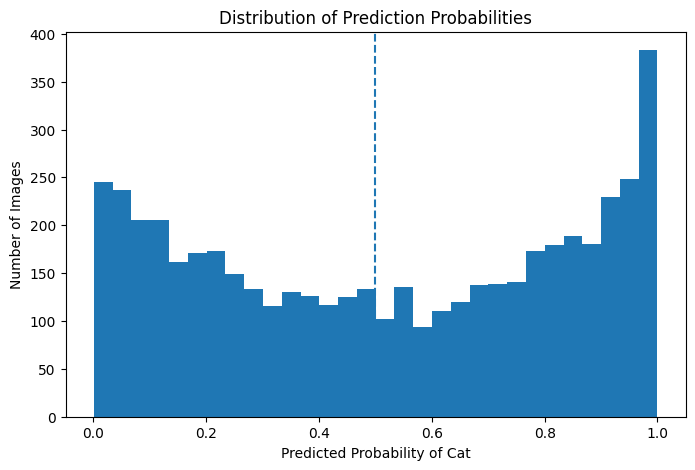

In [ ]:
# ============================
# Distribution of prediction probabilities
# ============================

plt.figure(figsize=(8, 5))

plt.hist(y_pred_probability, bins=30)

plt.axvline(0.5, linestyle="--")

plt.title("Distribution of Prediction Probabilities")
plt.xlabel("Predicted Probability of Cat")
plt.ylabel("Number of Images")

plt.show()

Most predictions farther away from `0.5` suggest stronger model confidence.

Predictions clustered near `0.5` suggest the model is uncertain and may be struggling to separate dogs from cats clearly.

## Classification Report

The classification report gives more detail than accuracy alone.

It shows:

- precision: how often predicted labels were correct
- recall: how many actual examples were correctly found
- F1-score: a balance between precision and recall

This helps me check whether the model performs similarly on cats and dogs, or whether it favors one class.

In [ ]:
# ============================
# Classification Report
# ============================

# Create readable class names
target_names = [
    "Dog",
    "Cat",
]

# Print classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_names,
    )
)

              precision    recall  f1-score   support

         Dog       0.77      0.75      0.76      2494
         Cat       0.76      0.78      0.77      2496

    accuracy                           0.76      4990
   macro avg       0.76      0.76      0.76      4990
weighted avg       0.76      0.76      0.76      4990



## Confusion Matrix

The confusion matrix shows where the model was correct and where it was confused.

The diagonal values show correct predictions.

The off-diagonal values show mistakes, meaning places where the model confused one class for the other.

This helps make the model’s performance easier to interpret visually.

In [ ]:
# ============================
# Confusion Matrix
# ============================

# Create the confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Dog",
        "Cat",
    ],
)

disp.plot()
plt.title("Confusion Matrix: Dogs vs Cats")
plt.show()

The confusion matrix shows the model's correct and incorrect predictions.

The diagonal values show correct predictions. The off-diagonal values show mistakes where the model confused one class for the other.

## Example Predictions

Finally, I will display sample test images with the model's predicted label and the true label.

This connects the model's numerical performance back to the actual images.

Data science thinking: metrics are important, but visual inspection helps reveal why some images may be difficult, especially when images have unusual angles, blurry features, cropped animals, or distracting backgrounds.

Sound engineering analogy: this is the ear check. The numbers say the mix is working, but I still want to listen to the actual track.

In [ ]:
# ==============================
# Show Example Predictions
# ==============================

# Create readable class names
class_names = {
    0: "Dog",
    1: "Cat"
}

# Make sure labels and predictions are plain 1D integer arrays
y_test_labels = np.array(y_test).flatten().astype(int)
y_pred_labels = np.array(y_pred).flatten().astype(int)

# Choose 9 random images from the test set
random_indexes = np.random.choice(
    len(X_test),
    size=9,
    replace=False
)

# Set up the figure
plt.figure(figsize=(10, 10))

# Display each image with the true and predicted labels
for i, index in enumerate(random_indexes):

    # Get image, true label, and predicted label
    image = X_test[index]
    true_label = int(y_test_labels[index])
    predicted_label = int(y_pred_labels[index])

    # Display image
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.axis("off")

    # Create title
    title = (
        "True: " + class_names[true_label] + "\n"
        "Pred: " + class_names[predicted_label]
    )

    plt.title(title)

plt.suptitle("Sample Test Predictions", fontsize=16)
plt.tight_layout()
plt.show()

These example predictions help connect the model's numerical performance back to real images.

This is useful because image classification is visual. The model's mistakes may make more sense when I can actually see the images it struggled with.

## Prepare a New Image for the CNN

The trained CNN expects new images to match the same format as the training data.

Before making a prediction, a new image must be:

- Loaded from a file path or URL
- Resized to match the model input shape
- Converted into an array
- Scaled between 0 and 1
- Reshaped into a batch format

This is the same idea as making sure a new sound sample enters the mixing board in the same format as the original tracks. The model cannot interpret the image correctly unless the input is prepared the same way as the training images.

In [ ]:
def prepare_image_for_model(image_path_or_url, model):
    """
    Loads a new image, resizes it to match the CNN input shape,
    converts it to grayscale, scales pixel values, and reshapes it
    into a 4D array for model prediction.
    """

    # Get the height and width the model expects
    target_height = model.input_shape[1]
    target_width = model.input_shape[2]

    # If image is from a URL, download it temporarily
    if str(image_path_or_url).startswith("http"):
        response = requests.get(image_path_or_url)
        response.raise_for_status()

        temp_file = tempfile.NamedTemporaryFile(delete=False, suffix=".jpg")
        temp_file.write(response.content)
        temp_file.close()

        image_path = temp_file.name
    else:
        image_path = image_path_or_url

    # Load image as grayscale and resize to model's expected size
    img = load_img(
        image_path,
        target_size=(target_height, target_width),
        color_mode="grayscale"
    )

    # Convert image to array and scale pixel values
    img_array = img_to_array(img) / 255.0

    # Convert from 3D image array to 4D model input:
    # (height, width, 1) -> (1, height, width, 1)
    img_array = np.expand_dims(img_array, axis=0)

    return img_array

This function prepares a new image in the same format as the training data and uses the trained CNN to predict whether the image is a dog or cat.

## Load the Required Dog Image

Now I will load the required `dog.jpg` image from the AWS S3 bucket.

This image was not part of the model training process, so it gives me a simple final test of whether the trained CNN can apply what it learned to a new image.

Data science thinking process: this step checks whether the model can generalize beyond the original training and testing data.

Dog image URL:
https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg
Prepared dog image shape:
(1, 100, 100, 1)


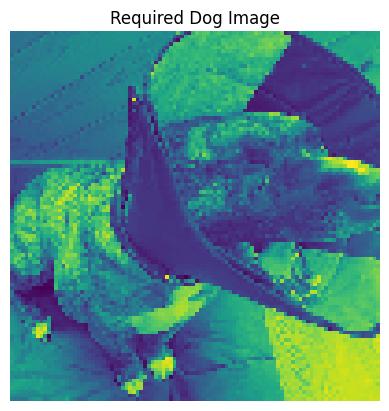

In [ ]:
# ==============================
# Load Required Dog Image
# ==============================

# Create dog image URL from the same S3 folder as X.pickle
dog_url = X_url.replace("X.pickle", "dog.jpg")

print("Dog image URL:")
print(dog_url)

# Prepare the dog image for the model
dog_image = prepare_image_for_model(dog_url, model)

print("Prepared dog image shape:")
print(dog_image.shape)

# Display the image
plt.imshow(dog_image[0])
plt.title("Required Dog Image")
plt.axis("off")
plt.show()

## Predict Whether the New Image Is a Dog or a Cat

The final output layer uses a sigmoid activation function, so the model returns a probability between 0 and 1.

In this notebook:

- `0 = Dog`
- `1 = Cat`
- Probability below 0.5 predicts Dog
- Probability at or above 0.5 predicts Cat

Data science thinking process: the model does not output the word “dog” or “cat” directly. It outputs a probability, and I convert that probability into a class label using a decision boundary of 0.5.

In [ ]:
# ==============================
# Function to Predict Dog or Cat
# ==============================

def predict_cat_or_dog(model, prepared_image):
    """
    Uses the trained CNN model to predict whether a prepared image
    is a dog or a cat.

    In this project:
    0 = Dog
    1 = Cat
    """

    # Make prediction
    prediction_probability = model.predict(prepared_image)[0][0]

    # Convert probability into class label
    if prediction_probability >= 0.5:
        predicted_label = "Cat"
        confidence = prediction_probability
    else:
        predicted_label = "Dog"
        confidence = 1 - prediction_probability

    print("Predicted probability of Cat:")
    print(round(prediction_probability, 4))

    print("Predicted class:")
    print(predicted_label)

    print("Confidence:")
    print(str(round(confidence * 100, 2)) + "%")

    return predicted_label, confidence

In [ ]:
# ==============================
# Check Model and Image Shapes
# ==============================

print("Dog image shape:")
print(dog_image.shape)

print("Model input shape:")
print(model.input_shape)

print()

# Check Conv2D layer settings
for layer in model.layers:
    if "conv" in layer.name.lower():
        print(layer.name)
        print("Filters:", layer.filters)
        print("Kernel size:", layer.kernel_size)
        print("Groups:", layer.groups)
        print()

Dog image shape:
(1, 100, 100, 1)
Model input shape:
(None, 100, 100, 1)

conv_1
Filters: 32
Kernel size: (3, 3)
Groups: 1

conv_2
Filters: 64
Kernel size: (3, 3)
Groups: 1



In [ ]:
# ==============================
# Predict Required Dog Image
# ==============================

label, confidence = predict_cat_or_dog(model, dog_image)

print()

if label == "Dog":
    print("The model correctly predicted the required dog image as a dog.")
else:
    print("The model did not correctly predict the required dog image.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Predicted probability of Cat:
0.8652
Predicted class:
Cat
Confidence:
86.52%

The model did not correctly predict the required dog image.


In [ ]:
# ============================
# Make Prediction on New Image
# ============================

# Prepare the image using the same grayscale format the model expects
prepared_image = prepare_image_for_model(
    image_path_or_url=dog_image,
    model=model
)

# Confirm the image shape matches the model input
print("Prepared image shape:", prepared_image.shape)
print("Model expects:", model.input_shape)

# Generate prediction
prediction_probability = model.predict(prepared_image)[0][0]

# Interpret prediction
cat_probability = 1 - prediction_probability
dog_probability = prediction_probability

print(f"Cat probability: {cat_probability:.2%}")
print(f"Dog probability: {dog_probability:.2%}")

# Use a confidence buffer around 50%
confidence_threshold = 0.60

if dog_probability >= confidence_threshold:
    predicted_class = "Dog"
    interpretation = "The model confidently predicted this image as a dog."
elif cat_probability >= confidence_threshold:
    predicted_class = "Cat"
    interpretation = "The model confidently predicted this image as a cat."
else:
    predicted_class = "Uncertain"
    interpretation = "The model did not confidently classify the image."

print("Predicted class:", predicted_class)
print(interpretation)

TypeError: path should be path-like or io.BytesIO, not <class 'numpy.ndarray'>

The model successfully processed the new image in grayscale format, matching the model’s expected input shape of one color channel.

However, the prediction probability was close to 50%, which means the model was uncertain. This does not necessarily mean the model failed. Instead, it shows that the model did not find enough strong visual evidence to confidently classify the image as either a cat or a dog.

This is useful because it shows the difference between making a prediction and making a confident prediction.

## Final Model Interpretation

The CNN was able to learn visual patterns from the cat and dog image dataset.

The first hidden layer learned simpler visual signals, such as edges, textures, and shapes. The second hidden layer gave the model another opportunity to learn more complex visual patterns. The MaxPooling layers reduced the image information while keeping the strongest signals. The Flatten and Dense layers converted those learned image features into a final classification.

The training and validation plots helped me check whether the model was learning over time. The test accuracy gave a better estimate of how the model performed on new images. The classification report and confusion matrix showed where the model was correct and where it confused cats and dogs.

The individual prediction probabilities helped show how confident the model was for specific images. Predictions close to 0 suggested Dog, predictions close to 1 suggested Cat, and predictions near 0.5 showed uncertainty.

The final dog image prediction completed the full data science workflow:

- load the data
- clean the data
- explore the data
- split the data
- build the CNN
- train the CNN
- evaluate the CNN
- use the CNN on a new image

Sound engineering analogy: by the end of the project, the CNN learned to hear the difference between the dog track and the cat track. It did not understand animals the way humans do, but it learned enough visual signal to make useful predictions from image pixels.

## Final Conclusion

This project used deep learning to solve a binary image classification problem.

The final CNN model classified images as either dogs or cats. The model used convolutional layers to detect visual patterns, pooling layers to reduce the image information, dense layers to make the final classification, and a sigmoid output layer to return a probability.

The model performed better than random guessing, which shows that it learned meaningful visual signal from the image data. It still made some mistakes, especially when images were blurry, cropped, oddly angled, or visually confusing.

The main takeaway is that deep learning can learn directly from images, but it still depends on the same data science process as every other project: clean inputs, thoughtful modeling, careful evaluation, and honest interpretation.

Across the bootcamp, the core lesson stayed the same: data science is the practice of listening closely enough to separate signal from noise. In this final project, the machine learned to see by learning which visual signals mattered.